# Soil-Moisture Forecasting

The aim of this notebook is to investigate whether future soil moisture can be predicted from recent soil conditions, rainfall, irrigation and temperature.

The previous physics analysis showed that a simple instantaneous water-balance model could not fully explain short-term changes in soil moisture. It also showed that a 15-minute persistence forecast performs very well during stable periods but becomes less reliable when meaningful wetting or drying occurs.

For this reason, I will begin with a one-hour forecasting horizon. At 15-minute sampling intervals, this means predicting soil moisture four observations into the future.

The first stage will establish simple forecasting baselines before moving to a nonlinear time-series model. All model evaluation will preserve chronological order to avoid using future observations to predict the past.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

data_file = Path("../data/processed/irrigation_model_data.csv")

data = pd.read_csv(
    data_file,
    parse_dates=["Timestamps"]
)

data = data.sort_values("Timestamps").reset_index(drop=True)

print("Rows:", len(data))
print("Columns:", len(data.columns))
print("Start:", data["Timestamps"].min())
print("End:", data["Timestamps"].max())

data.head()

Rows: 11770
Columns: 10
Start: 2022-08-01 00:15:00
End: 2023-02-28 23:45:00


,Timestamps,Port1,Port2,Port3,Port4,Port5,Port6,Rainfall,Irrigation,Temperature
0,2022-08-01 00:15:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,27.0
1,2022-08-01 00:30:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.9
2,2022-08-01 00:45:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
3,2022-08-01 01:00:00,0.257,0.132,0.172,0.204,0.2,0.155,0.0,0.0,26.8
4,2022-08-01 01:15:00,0.257,0.133,0.172,0.204,0.2,0.155,0.0,0.0,26.8


In [2]:
# Create a unique timestamp lookup
forecast_lookup = (
    data
    .sort_values("Timestamps")
    .drop_duplicates(
        subset="Timestamps",
        keep="first"
    )
    .copy()
)

forecast_lookup = forecast_lookup.set_index("Timestamps")

# Exact target time, one hour into the future
data["Target_time"] = (
    data["Timestamps"]
    + pd.Timedelta(hours=1)
)

# Find Port1 exactly one hour later
data["Port1_1h_future"] = (
    forecast_lookup["Port1"]
    .reindex(data["Target_time"])
    .to_numpy()
)

# Change in soil moisture over the forecast horizon
data["Delta_theta_1h"] = (
    data["Port1_1h_future"]
    - data["Port1"]
)

print("Total rows:", len(data))
print(
    "Rows with valid 1-hour target:",
    data["Port1_1h_future"].notna().sum()
)

print(
    "Rows without valid 1-hour target:",
    data["Port1_1h_future"].isna().sum()
)

data[
    [
        "Timestamps",
        "Port1",
        "Target_time",
        "Port1_1h_future",
        "Delta_theta_1h"
    ]
].head(10)

Total rows: 11770
Rows with valid 1-hour target: 11453
Rows without valid 1-hour target: 317


,Timestamps,Port1,Target_time,Port1_1h_future,Delta_theta_1h
0,2022-08-01 00:15:00,0.257,2022-08-01 01:15:00,0.257,0.000
1,2022-08-01 00:30:00,0.257,2022-08-01 01:30:00,0.256,-0.001
2,2022-08-01 00:45:00,0.257,2022-08-01 01:45:00,0.256,-0.001
3,2022-08-01 01:00:00,0.257,2022-08-01 02:00:00,0.256,-0.001
4,2022-08-01 01:15:00,0.257,2022-08-01 02:15:00,0.255,-0.002
5,2022-08-01 01:30:00,0.256,2022-08-01 02:30:00,0.255,-0.001
6,2022-08-01 01:45:00,0.256,2022-08-01 02:45:00,0.255,-0.001
7,2022-08-01 02:00:00,0.256,2022-08-01 03:00:00,0.255,-0.001
8,2022-08-01 02:15:00,0.255,2022-08-01 03:15:00,0.255,0.000
9,2022-08-01 02:30:00,0.255,2022-08-01 03:30:00,0.254,-0.001


In [3]:
forecast_data = data[
    data["Port1_1h_future"].notna()
].copy()

forecast_train = forecast_data[
    forecast_data["Timestamps"] <= pd.Timestamp("2022-11-01 00:30:00")
].copy()

forecast_test = forecast_data[
    forecast_data["Timestamps"] > pd.Timestamp("2022-11-01 00:30:00")
].copy()

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Persistence prediction
forecast_test["Persistence_1h"] = forecast_test["Port1"]

persistence_1h_mae = mean_absolute_error(
    forecast_test["Port1_1h_future"],
    forecast_test["Persistence_1h"]
)

persistence_1h_rmse = np.sqrt(
    mean_squared_error(
        forecast_test["Port1_1h_future"],
        forecast_test["Persistence_1h"]
    )
)

persistence_1h_r2 = r2_score(
    forecast_test["Port1_1h_future"],
    forecast_test["Persistence_1h"]
)

print("Training observations:", len(forecast_train))
print("Testing observations:", len(forecast_test))

print("\nTraining period:")
print(
    forecast_train["Timestamps"].min(),
    "to",
    forecast_train["Timestamps"].max()
)

print("\nTesting period:")
print(
    forecast_test["Timestamps"].min(),
    "to",
    forecast_test["Timestamps"].max()
)

print("\nONE-HOUR PERSISTENCE BASELINE")
print("MAE:", persistence_1h_mae)
print("RMSE:", persistence_1h_rmse)
print("R²:", persistence_1h_r2)

Training observations: 8838
Testing observations: 2615

Training period:
2022-08-01 00:15:00 to 2022-11-01 00:30:00

Testing period:
2022-11-01 00:45:00 to 2023-02-28 22:45:00

ONE-HOUR PERSISTENCE BASELINE
MAE: 0.0002703632887189294
RMSE: 0.0015584224999455444
R²: 0.9905975978617052


In [4]:
changing_1h = forecast_test[
    forecast_test["Delta_theta_1h"].abs() >= 0.001
].copy()

wetting_1h = forecast_test[
    forecast_test["Delta_theta_1h"] >= 0.001
].copy()

drying_1h = forecast_test[
    forecast_test["Delta_theta_1h"] <= -0.001
].copy()

print("Total test observations:", len(forecast_test))

print(
    "Meaningful changes:",
    len(changing_1h)
)

print(
    "Percentage changing:",
    100 * len(changing_1h) / len(forecast_test)
)

print("\nWetting periods:", len(wetting_1h))
print("Drying periods:", len(drying_1h))

print(
    "\nMean 1-hour change:",
    forecast_test["Delta_theta_1h"].mean()
)

print(
    "Largest 1-hour increase:",
    forecast_test["Delta_theta_1h"].max()
)

print(
    "Largest 1-hour decrease:",
    forecast_test["Delta_theta_1h"].min()
)

Total test observations: 2615
Meaningful changes: 426
Percentage changing: 16.290630975143404

Wetting periods: 154
Drying periods: 272

Mean 1-hour change: 5.850860420650088e-05
Largest 1-hour increase: 0.039000000000000035
Largest 1-hour decrease: -0.0030000000000000027


In [5]:
from sklearn.ensemble import RandomForestRegressor

features = [
    "Port1",
    "Port2",
    "Port3",
    "Port4",
    "Port5",
    "Port6",
    "Rainfall",
    "Irrigation",
    "Temperature"
]

target = "Port1_1h_future"

ml_data = forecast_data.dropna(
    subset=features + [target]
).copy()

ml_train = ml_data[
    ml_data["Timestamps"]
    <= pd.Timestamp("2022-11-01 00:30:00")
].copy()

ml_test = ml_data[
    ml_data["Timestamps"]
    > pd.Timestamp("2022-11-01 00:30:00")
].copy()

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    ml_train[features],
    ml_train[target]
)

rf_predictions = rf_model.predict(
    ml_test[features]
)

rf_mae = mean_absolute_error(
    ml_test[target],
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        ml_test[target],
        rf_predictions
    )
)

rf_r2 = r2_score(
    ml_test[target],
    rf_predictions
)

print("Training observations:", len(ml_train))
print("Testing observations:", len(ml_test))

print("\nRANDOM FOREST")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

print("\nPERSISTENCE")
print("MAE:", persistence_1h_mae)
print("RMSE:", persistence_1h_rmse)
print("R²:", persistence_1h_r2)

Training observations: 8838
Testing observations: 2101

RANDOM FOREST
MAE: 0.0009060084794190204
RMSE: 0.0023676838513125233
R²: 0.9745916509475842

PERSISTENCE
MAE: 0.0002703632887189294
RMSE: 0.0015584224999455444
R²: 0.9905975978617052


In [6]:
# Persistence prediction on exactly the same rows
# used to evaluate the Random Forest
ml_test["Persistence_1h"] = ml_test["Port1"]

fair_persistence_mae = mean_absolute_error(
    ml_test[target],
    ml_test["Persistence_1h"]
)

fair_persistence_rmse = np.sqrt(
    mean_squared_error(
        ml_test[target],
        ml_test["Persistence_1h"]
    )
)

fair_persistence_r2 = r2_score(
    ml_test[target],
    ml_test["Persistence_1h"]
)

print("SAME TEST OBSERVATIONS:", len(ml_test))

print("\nRANDOM FOREST")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

print("\nPERSISTENCE")
print("MAE:", fair_persistence_mae)
print("RMSE:", fair_persistence_rmse)
print("R²:", fair_persistence_r2)

print("\nRF MAE relative to persistence:")
print(rf_mae / fair_persistence_mae)

print("\nRF RMSE relative to persistence:")
print(rf_rmse / fair_persistence_rmse)

SAME TEST OBSERVATIONS: 2101

RANDOM FOREST
MAE: 0.0009060084794190204
RMSE: 0.0023676838513125233
R²: 0.9745916509475842

PERSISTENCE
MAE: 0.0003136601618277012
RMSE: 0.0017309512671898094
R²: 0.9864200333032437

RF MAE relative to persistence:
2.8885035132918984

RF RMSE relative to persistence:
1.3678512481500684


In [7]:
sequence_length = 12  # 12 observations × 15 minutes = 3 hours

sequence_check = data.copy()

sequence_check["History_start"] = (
    sequence_check["Timestamps"].shift(sequence_length - 1)
)

sequence_check["History_duration"] = (
    sequence_check["Timestamps"]
    - sequence_check["History_start"]
)

expected_duration = pd.Timedelta(
    minutes=15 * (sequence_length - 1)
)

sequence_check["Continuous_3h_history"] = (
    sequence_check["History_duration"]
    == expected_duration
)

# A sequence also needs an exact target one hour later
valid_sequence_rows = sequence_check[
    sequence_check["Continuous_3h_history"]
    & sequence_check["Port1_1h_future"].notna()
].copy()

print(
    "Rows with continuous 3-hour history:",
    sequence_check["Continuous_3h_history"].sum()
)

print(
    "Rows with continuous history and valid 1-hour target:",
    len(valid_sequence_rows)
)

print(
    "Percentage of dataset usable:",
    100 * len(valid_sequence_rows) / len(data)
)

Rows with continuous 3-hour history: 11234
Rows with continuous history and valid 1-hour target: 11162
Percentage of dataset usable: 94.83432455395072


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Training device:", device)

PyTorch version: 2.14.0
Training device: mps


In [9]:
lstm_data = data.copy()

# Record whether the irrigation measurement was missing
lstm_data["Irrigation_missing"] = (
    lstm_data["Irrigation"].isna().astype(int)
)

print(
    "Missing irrigation observations:",
    lstm_data["Irrigation_missing"].sum()
)

print(
    "Recorded irrigation observations:",
    (lstm_data["Irrigation_missing"] == 0).sum()
)

print(
    "Percentage missing:",
    100 * lstm_data["Irrigation_missing"].mean()
)

# Fill missing numerical values only after creating the indicator
lstm_data["Irrigation_filled"] = (
    lstm_data["Irrigation"].fillna(0)
)

lstm_data[
    [
        "Timestamps",
        "Irrigation",
        "Irrigation_filled",
        "Irrigation_missing"
    ]
].tail(10)

Missing irrigation observations: 652
Recorded irrigation observations: 11118
Percentage missing: 5.539507221750212


,Timestamps,Irrigation,Irrigation_filled,Irrigation_missing
11760,2023-02-28 21:30:00,0.0,0.0,0
11761,2023-02-28 21:45:00,0.0,0.0,0
11762,2023-02-28 22:00:00,0.0,0.0,0
11763,2023-02-28 22:15:00,0.0,0.0,0
11764,2023-02-28 22:30:00,0.0,0.0,0
11765,2023-02-28 22:45:00,0.0,0.0,0
11766,2023-02-28 23:00:00,0.0,0.0,0
11767,2023-02-28 23:15:00,0.0,0.0,0
11768,2023-02-28 23:30:00,0.0,0.0,0
11769,2023-02-28 23:45:00,0.0,0.0,0


In [10]:
# Keep only rows with a valid one-hour-ahead target
lstm_forecast_data = lstm_data[
    lstm_data["Port1_1h_future"].notna()
].copy()

lstm_forecast_data = (
    lstm_forecast_data
    .sort_values("Timestamps")
    .reset_index(drop=True)
)

n = len(lstm_forecast_data)

train_end = int(n * 0.70)
val_end = int(n * 0.80)

train_data = lstm_forecast_data.iloc[:train_end].copy()
val_data = lstm_forecast_data.iloc[train_end:val_end].copy()
test_data = lstm_forecast_data.iloc[val_end:].copy()

print("Total usable observations:", n)

print("\nTRAIN")
print("Rows:", len(train_data))
print(
    "Period:",
    train_data["Timestamps"].min(),
    "to",
    train_data["Timestamps"].max()
)

print("\nVALIDATION")
print("Rows:", len(val_data))
print(
    "Period:",
    val_data["Timestamps"].min(),
    "to",
    val_data["Timestamps"].max()
)

print("\nTEST")
print("Rows:", len(test_data))
print(
    "Period:",
    test_data["Timestamps"].min(),
    "to",
    test_data["Timestamps"].max()
)

Total usable observations: 11453

TRAIN
Rows: 8017
Period: 2022-08-01 00:15:00 to 2022-10-23 12:15:00

VALIDATION
Rows: 1145
Period: 2022-10-23 12:30:00 to 2022-11-04 09:30:00

TEST
Rows: 2291
Period: 2022-11-04 09:45:00 to 2023-02-28 22:45:00


In [11]:
lstm_features = [
    "Port1",
    "Port2",
    "Port3",
    "Port4",
    "Port5",
    "Port6",
    "Rainfall",
    "Irrigation_filled",
    "Irrigation_missing",
    "Temperature"
]

lstm_target = "Port1_1h_future"

print("Number of input features:", len(lstm_features))

print("\nMissing values in each feature:")
print(
    lstm_forecast_data[lstm_features]
    .isna()
    .sum()
)

print(
    "\nMissing target values:",
    lstm_forecast_data[lstm_target]
    .isna()
    .sum()
)

Number of input features: 10

Missing values in each feature:
Port1                 0
Port2                 0
Port3                 0
Port4                 0
Port5                 0
Port6                 0
Rainfall              0
Irrigation_filled     0
Irrigation_missing    0
Temperature           0
dtype: int64

Missing target values: 0


In [12]:
from sklearn.preprocessing import StandardScaler

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

# Fit ONLY on training data
feature_scaler.fit(
    train_data[lstm_features]
)

target_scaler.fit(
    train_data[[lstm_target]]
)

# Transform all three sets using the training scalers
X_train_scaled = feature_scaler.transform(
    train_data[lstm_features]
)

X_val_scaled = feature_scaler.transform(
    val_data[lstm_features]
)

X_test_scaled = feature_scaler.transform(
    test_data[lstm_features]
)

y_train_scaled = target_scaler.transform(
    train_data[[lstm_target]]
)

y_val_scaled = target_scaler.transform(
    val_data[[lstm_target]]
)

y_test_scaled = target_scaler.transform(
    test_data[[lstm_target]]
)

print("X train shape:", X_train_scaled.shape)
print("X validation shape:", X_val_scaled.shape)
print("X test shape:", X_test_scaled.shape)

print("\ny train shape:", y_train_scaled.shape)
print("y validation shape:", y_val_scaled.shape)
print("y test shape:", y_test_scaled.shape)

print(
    "\nTraining feature means after scaling:"
)
print(
    np.round(X_train_scaled.mean(axis=0), 3)
)

print(
    "\nTraining feature standard deviations:"
)
print(
    np.round(X_train_scaled.std(axis=0), 3)
)

X train shape: (8017, 10)
X validation shape: (1145, 10)
X test shape: (2291, 10)

y train shape: (8017, 1)
y validation shape: (1145, 1)
y test shape: (2291, 1)

Training feature means after scaling:
[-0.  0. -0. -0. -0. -0. -0. -0.  0. -0.]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]


In [13]:
print("TRAIN")
print(
    train_data["Irrigation_missing"].value_counts().sort_index()
)

print("\nVALIDATION")
print(
    val_data["Irrigation_missing"].value_counts().sort_index()
)

print("\nTEST")
print(
    test_data["Irrigation_missing"].value_counts().sort_index()
)

print("\nMissing percentages")

print(
    "Train:",
    100 * train_data["Irrigation_missing"].mean()
)

print(
    "Validation:",
    100 * val_data["Irrigation_missing"].mean()
)

print(
    "Test:",
    100 * test_data["Irrigation_missing"].mean()
)

TRAIN
Irrigation_missing
0    8017
Name: count, dtype: int64

VALIDATION
Irrigation_missing
0    1145
Name: count, dtype: int64

TEST
Irrigation_missing
0    1777
1     514
Name: count, dtype: int64

Missing percentages
Train: 0.0
Validation: 0.0
Test: 22.435617634220865


In [14]:
baseline_features = [
    "Port1",
    "Port2",
    "Port3",
    "Port4",
    "Port5",
    "Port6",
    "Rainfall",
    "Irrigation_filled",
    "Temperature"
]

sequence_length = 12

def create_sequences(df, features, target, sequence_length):
    X = []
    y = []
    timestamps = []

    df = df.sort_values("Timestamps").reset_index(drop=True)

    for i in range(sequence_length - 1, len(df)):

        start = i - sequence_length + 1

        # Extract timestamps for this candidate sequence
        times = df.loc[start:i, "Timestamps"]

        # Require exactly 15 minutes between every observation
        gaps = times.diff().dropna()

        if not (gaps == pd.Timedelta(minutes=15)).all():
            continue

        X.append(
            df.loc[start:i, features].to_numpy(dtype=np.float32)
        )

        y.append(
            df.loc[i, target]
        )

        timestamps.append(
            df.loc[i, "Timestamps"]
        )

    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32).reshape(-1, 1),
        np.array(timestamps)
    )


X_train_raw, y_train_raw, train_times = create_sequences(
    train_data,
    baseline_features,
    lstm_target,
    sequence_length
)

X_val_raw, y_val_raw, val_times = create_sequences(
    val_data,
    baseline_features,
    lstm_target,
    sequence_length
)

X_test_raw, y_test_raw, test_times = create_sequences(
    test_data,
    baseline_features,
    lstm_target,
    sequence_length
)

print("TRAIN")
print("X:", X_train_raw.shape)
print("y:", y_train_raw.shape)

print("\nVALIDATION")
print("X:", X_val_raw.shape)
print("y:", y_val_raw.shape)

print("\nTEST")
print("X:", X_test_raw.shape)
print("y:", y_test_raw.shape)

print("\nFeatures per time step:", X_train_raw.shape[2])
print("Time steps per sequence:", X_train_raw.shape[1])

TRAIN
X: (8006, 12, 9)
y: (8006, 1)

VALIDATION
X: (1117, 12, 9)
y: (1117, 1)

TEST
X: (2015, 12, 9)
y: (2015, 1)

Features per time step: 9
Time steps per sequence: 12


In [15]:
from sklearn.preprocessing import StandardScaler

sequence_feature_scaler = StandardScaler()
sequence_target_scaler = StandardScaler()

# Flatten training sequences temporarily:
# (samples, time_steps, features) -> (samples*time_steps, features)
train_2d = X_train_raw.reshape(
    -1,
    X_train_raw.shape[-1]
)

# Fit feature scaler ONLY on training sequences
sequence_feature_scaler.fit(train_2d)

def scale_sequences(X, scaler):
    original_shape = X.shape

    X_2d = X.reshape(
        -1,
        original_shape[-1]
    )

    X_scaled = scaler.transform(X_2d)

    return X_scaled.reshape(original_shape)


X_train = scale_sequences(
    X_train_raw,
    sequence_feature_scaler
)

X_val = scale_sequences(
    X_val_raw,
    sequence_feature_scaler
)

X_test = scale_sequences(
    X_test_raw,
    sequence_feature_scaler
)

# Fit target scaler ONLY on training targets
sequence_target_scaler.fit(y_train_raw)

y_train = sequence_target_scaler.transform(
    y_train_raw
)

y_val = sequence_target_scaler.transform(
    y_val_raw
)

y_test = sequence_target_scaler.transform(
    y_test_raw
)

print("TRAIN:", X_train.shape, y_train.shape)
print("VALIDATION:", X_val.shape, y_val.shape)
print("TEST:", X_test.shape, y_test.shape)

print(
    "\nTraining feature means:",
    np.round(
        X_train.reshape(-1, X_train.shape[-1]).mean(axis=0),
        3
    )
)

print(
    "Training feature std:",
    np.round(
        X_train.reshape(-1, X_train.shape[-1]).std(axis=0),
        3
    )
)

print(
    "\nTraining target mean:",
    round(float(y_train.mean()), 3)
)

print(
    "Training target std:",
    round(float(y_train.std()), 3)
)

TRAIN: (8006, 12, 9) (8006, 1)
VALIDATION: (1117, 12, 9) (1117, 1)
TEST: (2015, 12, 9) (2015, 1)

Training feature means: [-0. -0. -0.  0. -0.  0. -0. -0.  0.]
Training feature std: [1.    1.    1.    1.    1.    1.    1.    0.999 1.   ]

Training target mean: 0.0
Training target std: 1.0


In [16]:
# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.float32
)

print("TRAIN")
print("X:", X_train_tensor.shape)
print("y:", y_train_tensor.shape)

print("\nVALIDATION")
print("X:", X_val_tensor.shape)
print("y:", y_val_tensor.shape)

print("\nTEST")
print("X:", X_test_tensor.shape)
print("y:", y_test_tensor.shape)

print("\nData type:", X_train_tensor.dtype)

TRAIN
X: torch.Size([8006, 12, 9])
y: torch.Size([8006, 1])

VALIDATION
X: torch.Size([1117, 12, 9])
y: torch.Size([1117, 1])

TEST
X: torch.Size([2015, 12, 9])
y: torch.Size([2015, 1])

Data type: torch.float32


In [17]:
batch_size = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

# Inspect one training batch
X_batch, y_batch = next(iter(train_loader))

print("\nOne training batch")
print("X shape:", X_batch.shape)
print("y shape:", y_batch.shape)

Training batches: 126
Validation batches: 18
Test batches: 32

One training batch
X shape: torch.Size([64, 12, 9])
y shape: torch.Size([64, 1])


In [18]:
class SoilMoistureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.output = nn.Linear(
            hidden_size,
            1
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        # Use the representation from the final time step
        last_step = lstm_out[:, -1, :]

        return self.output(last_step)


model = SoilMoistureLSTM(
    input_size=len(baseline_features),
    hidden_size=32,
    num_layers=1
).to(device)

print(model)

total_parameters = sum(
    p.numel() for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTotal parameters:", total_parameters)
print("Trainable parameters:", trainable_parameters)
print("Device:", device)

SoilMoistureLSTM(
  (lstm): LSTM(9, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 5537
Trainable parameters: 5537
Device: mps


In [19]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001


In [20]:
num_epochs = 50
patience = 7

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # Training
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    train_loss = running_train_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

    val_loss = running_val_loss / len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    # Save the best validation model
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    # Stop if validation performance stops improving
    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break


# Restore the best model
model.load_state_dict(best_model_state)

print("\nBest validation loss:", best_val_loss)
print("Epochs completed:", len(train_losses))

Epoch 01 | Train Loss: 0.246442 | Val Loss: 0.017236
Epoch 02 | Train Loss: 0.016376 | Val Loss: 0.003108
Epoch 03 | Train Loss: 0.009898 | Val Loss: 0.003017
Epoch 04 | Train Loss: 0.007528 | Val Loss: 0.002052
Epoch 05 | Train Loss: 0.006104 | Val Loss: 0.002988
Epoch 06 | Train Loss: 0.005433 | Val Loss: 0.001707
Epoch 07 | Train Loss: 0.004750 | Val Loss: 0.002383
Epoch 08 | Train Loss: 0.003811 | Val Loss: 0.002404
Epoch 09 | Train Loss: 0.003135 | Val Loss: 0.002775
Epoch 10 | Train Loss: 0.002665 | Val Loss: 0.003074
Epoch 11 | Train Loss: 0.002058 | Val Loss: 0.004452
Epoch 12 | Train Loss: 0.002036 | Val Loss: 0.004421
Epoch 13 | Train Loss: 0.001974 | Val Loss: 0.002997

Early stopping triggered.

Best validation loss: 0.0017065277903431637
Epochs completed: 13


In [21]:
model.eval()

test_predictions_scaled = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        test_predictions_scaled.append(
            predictions.cpu().numpy()
        )

test_predictions_scaled = np.vstack(
    test_predictions_scaled
)

# Convert predictions back to original soil-moisture units
lstm_predictions = (
    sequence_target_scaler.inverse_transform(
        test_predictions_scaled
    ).ravel()
)

actual_test = y_test_raw.ravel()

# Current Port1 value at the end of each sequence
persistence_predictions = X_test_raw[:, -1, 0]

# LSTM metrics
lstm_mae = mean_absolute_error(
    actual_test,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        lstm_predictions
    )
)

lstm_r2 = r2_score(
    actual_test,
    lstm_predictions
)

# Persistence on exactly the same test sequences
persistence_mae = mean_absolute_error(
    actual_test,
    persistence_predictions
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        persistence_predictions
    )
)

persistence_r2 = r2_score(
    actual_test,
    persistence_predictions
)

print("SAME TEST SEQUENCES:", len(actual_test))

print("\nLSTM")
print("MAE:", lstm_mae)
print("RMSE:", lstm_rmse)
print("R²:", lstm_r2)

print("\nPERSISTENCE")
print("MAE:", persistence_mae)
print("RMSE:", persistence_rmse)
print("R²:", persistence_r2)

print("\nLSTM MAE relative to persistence:")
print(lstm_mae / persistence_mae)

print("\nLSTM RMSE relative to persistence:")
print(lstm_rmse / persistence_rmse)

SAME TEST SEQUENCES: 2015

LSTM
MAE: 0.004491826519370079
RMSE: 0.005316602850687137
R²: 0.7942512631416321

PERSISTENCE
MAE: 0.00019255586084909737
RMSE: 0.0007626517319551768
R²: 0.995766282081604

LSTM MAE relative to persistence:
23.327394448358255

LSTM RMSE relative to persistence:
6.971206683104483


In [22]:
test_change = actual_test - persistence_predictions

meaningful_mask = np.abs(test_change) >= 0.001
wetting_mask = test_change >= 0.001
drying_mask = test_change <= -0.001

print("Total test sequences:", len(actual_test))
print("Meaningful changes:", meaningful_mask.sum())
print("Wetting events:", wetting_mask.sum())
print("Drying events:", drying_mask.sum())


def event_metrics(mask, name):
    y_true = actual_test[mask]
    y_lstm = lstm_predictions[mask]
    y_persistence = persistence_predictions[mask]

    print(f"\n{name}")
    print("Number of observations:", mask.sum())

    print("\nLSTM")
    print(
        "MAE:",
        mean_absolute_error(y_true, y_lstm)
    )
    print(
        "RMSE:",
        np.sqrt(mean_squared_error(y_true, y_lstm))
    )

    print("\nPersistence")
    print(
        "MAE:",
        mean_absolute_error(y_true, y_persistence)
    )
    print(
        "RMSE:",
        np.sqrt(mean_squared_error(y_true, y_persistence))
    )


event_metrics(
    meaningful_mask,
    "ALL MEANINGFUL CHANGES"
)

event_metrics(
    wetting_mask,
    "WETTING EVENTS"
)

event_metrics(
    drying_mask,
    "DRYING EVENTS"
)

Total test sequences: 2015
Meaningful changes: 190
Wetting events: 78
Drying events: 112

ALL MEANINGFUL CHANGES
Number of observations: 190

LSTM
MAE: 0.00575310830026865
RMSE: 0.007088846396443197

Persistence
MAE: 0.001526322797872126
RMSE: 0.0023775294846691947

WETTING EVENTS
Number of observations: 78

LSTM
MAE: 0.006700922269374132
RMSE: 0.008570151887938747

Persistence
MAE: 0.0022692366037517786
RMSE: 0.003506406407079205

DRYING EVENTS
Number of observations: 112

LSTM
MAE: 0.005093022249639034
RMSE: 0.005839312249735123

Persistence
MAE: 0.0010089362040162086
RMSE: 0.0010133119465564023


In [23]:
comparison_columns = [
    "Port1",
    "Rainfall",
    "Irrigation_filled",
    "Temperature"
]

def period_summary(df, name):
    print(f"\n{name}")
    print("Rows:", len(df))

    for column in comparison_columns:
        values = df[column]

        print(
            f"{column:20s} "
            f"mean={values.mean():.4f}  "
            f"std={values.std():.4f}  "
            f"min={values.min():.4f}  "
            f"max={values.max():.4f}"
        )


period_summary(train_data, "TRAIN")
period_summary(val_data, "VALIDATION")
period_summary(test_data, "TEST")



TRAIN
Rows: 8017
Port1                mean=0.2151  std=0.0391  min=0.1590  max=0.3390
Rainfall             mean=0.0115  std=0.2498  min=0.0000  max=13.2000
Irrigation_filled    mean=0.0837  std=0.3302  min=0.0000  max=7.6600
Temperature          mean=24.6645  std=4.2389  min=15.1000  max=37.9000

VALIDATION
Rows: 1145
Port1                mean=0.2352  std=0.0080  min=0.2230  max=0.2480
Rainfall             mean=0.0000  std=0.0000  min=0.0000  max=0.0000
Irrigation_filled    mean=0.0000  std=0.0006  min=0.0000  max=0.0200
Temperature          mean=20.0279  std=2.4298  min=15.2000  max=26.2000

TEST
Rows: 2291
Port1                mean=0.2530  std=0.0142  min=0.2220  max=0.3050
Rainfall             mean=0.0100  std=0.0961  min=0.0000  max=1.8000
Irrigation_filled    mean=0.0004  std=0.0209  min=0.0000  max=1.0000
Temperature          mean=14.0619  std=4.1004  min=2.1000  max=22.3000


In [24]:
prediction_error = lstm_predictions - actual_test

print("Actual test moisture")
print("Mean:", actual_test.mean())

print("\nLSTM predictions")
print("Mean:", lstm_predictions.mean())

print("\nPersistence predictions")
print("Mean:", persistence_predictions.mean())

print("\nLSTM prediction error")
print("Mean error:", prediction_error.mean())
print("Median error:", np.median(prediction_error))

print("\nPrediction range")
print(
    "Actual:",
    actual_test.min(),
    "to",
    actual_test.max()
)

print(
    "LSTM:",
    lstm_predictions.min(),
    "to",
    lstm_predictions.max()
)

print(
    "Persistence:",
    persistence_predictions.min(),
    "to",
    persistence_predictions.max()
)

Actual test moisture
Mean: 0.25094888

LSTM predictions
Mean: 0.2505649

Persistence predictions
Mean: 0.25092804

LSTM prediction error
Mean error: -0.00038397708
Median error: 0.001644522

Prediction range
Actual: 0.222 to 0.302
LSTM: 0.22540185 to 0.29045063
Persistence: 0.222 to 0.303


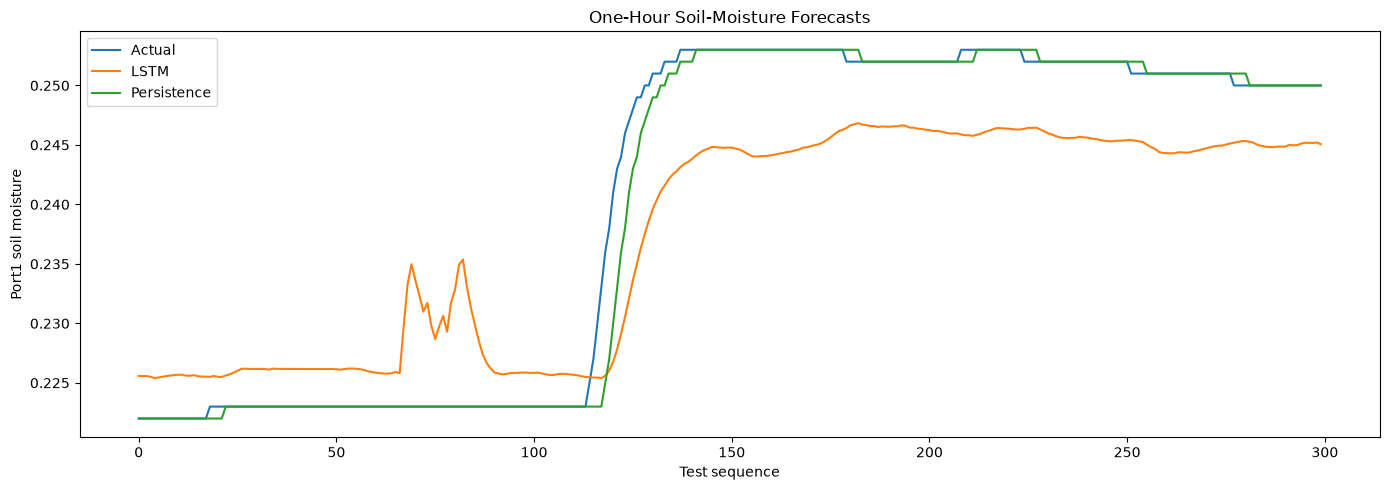

In [25]:
plot_points = 300

plt.figure(figsize=(14, 5))

plt.plot(
    actual_test[:plot_points],
    label="Actual"
)

plt.plot(
    lstm_predictions[:plot_points],
    label="LSTM"
)

plt.plot(
    persistence_predictions[:plot_points],
    label="Persistence"
)

plt.xlabel("Test sequence")
plt.ylabel("Port1 soil moisture")
plt.title("One-Hour Soil-Moisture Forecasts")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# Current soil moisture is the final Port1 value in each sequence
train_current = X_train_raw[:, -1, 0]
val_current = X_val_raw[:, -1, 0]
test_current = X_test_raw[:, -1, 0]

# One-hour soil-moisture change
y_train_change_raw = (
    y_train_raw.ravel() - train_current
).reshape(-1, 1)

y_val_change_raw = (
    y_val_raw.ravel() - val_current
).reshape(-1, 1)

y_test_change_raw = (
    y_test_raw.ravel() - test_current
).reshape(-1, 1)

print("TRAIN CHANGE")
print("Mean:", y_train_change_raw.mean())
print("Std:", y_train_change_raw.std())
print("Min:", y_train_change_raw.min())
print("Max:", y_train_change_raw.max())

print("\nVALIDATION CHANGE")
print("Mean:", y_val_change_raw.mean())
print("Std:", y_val_change_raw.std())
print("Min:", y_val_change_raw.min())
print("Max:", y_val_change_raw.max())

print("\nTEST CHANGE")
print("Mean:", y_test_change_raw.mean())
print("Std:", y_test_change_raw.std())
print("Min:", y_test_change_raw.min())
print("Max:", y_test_change_raw.max())


TRAIN CHANGE
Mean: -3.2475673e-06
Std: 0.004046351
Min: -0.011000007
Max: 0.167

VALIDATION CHANGE
Mean: -8.5944455e-05
Std: 0.00039666085
Min: -0.001000002
Max: 0.001000002

TEST CHANGE
Mean: 2.0843618e-05
Std: 0.00076236686
Min: -0.002000004
Max: 0.011000007


In [27]:
change_target_scaler = StandardScaler()

y_train_change = change_target_scaler.fit_transform(
    y_train_change_raw
)

y_val_change = change_target_scaler.transform(
    y_val_change_raw
)

y_test_change = change_target_scaler.transform(
    y_test_change_raw
)

print("TRAIN")
print("Mean:", y_train_change.mean())
print("Std:", y_train_change.std())

print("\nVALIDATION")
print("Mean:", y_val_change.mean())
print("Std:", y_val_change.std())

print("\nTEST")
print("Mean:", y_test_change.mean())
print("Std:", y_test_change.std())

print("\nScaler mean:", change_target_scaler.mean_[0])
print("Scaler scale:", change_target_scaler.scale_[0])


TRAIN
Mean: -9.529596e-10
Std: 1.0

VALIDATION
Mean: -0.020437397
Std: 0.09802927

TEST
Mean: 0.0059538037
Std: 0.1884085

Scaler mean: -3.247567185633724e-06
Scaler scale: 0.004046351368656163


In [28]:
y_train_change_tensor = torch.tensor(
    y_train_change,
    dtype=torch.float32
)

y_val_change_tensor = torch.tensor(
    y_val_change,
    dtype=torch.float32
)

y_test_change_tensor = torch.tensor(
    y_test_change,
    dtype=torch.float32
)

print("TRAIN")
print("X:", X_train_tensor.shape)
print("y change:", y_train_change_tensor.shape)

print("\nVALIDATION")
print("X:", X_val_tensor.shape)
print("y change:", y_val_change_tensor.shape)

print("\nTEST")
print("X:", X_test_tensor.shape)
print("y change:", y_test_change_tensor.shape)

print("\nTarget type:", y_train_change_tensor.dtype)

TRAIN
X: torch.Size([8006, 12, 9])
y change: torch.Size([8006, 1])

VALIDATION
X: torch.Size([1117, 12, 9])
y change: torch.Size([1117, 1])

TEST
X: torch.Size([2015, 12, 9])
y change: torch.Size([2015, 1])

Target type: torch.float32


In [29]:
batch_size = 64

residual_train_dataset = TensorDataset(
    X_train_tensor,
    y_train_change_tensor
)

residual_val_dataset = TensorDataset(
    X_val_tensor,
    y_val_change_tensor
)

residual_test_dataset = TensorDataset(
    X_test_tensor,
    y_test_change_tensor
)

residual_train_loader = DataLoader(
    residual_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

residual_val_loader = DataLoader(
    residual_val_dataset,
    batch_size=batch_size,
    shuffle=False
)

residual_test_loader = DataLoader(
    residual_test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(residual_train_loader))
print("Validation batches:", len(residual_val_loader))
print("Test batches:", len(residual_test_loader))

X_batch, y_batch = next(iter(residual_train_loader))

print("\nOne training batch")
print("X shape:", X_batch.shape)
print("Change target shape:", y_batch.shape)

Training batches: 126
Validation batches: 18
Test batches: 32

One training batch
X shape: torch.Size([64, 12, 9])
Change target shape: torch.Size([64, 1])


In [30]:
residual_model = SoilMoistureLSTM(
    input_size=len(baseline_features),
    hidden_size=32,
    num_layers=1
).to(device)

residual_criterion = nn.MSELoss()

residual_optimizer = torch.optim.Adam(
    residual_model.parameters(),
    lr=0.001
)

print(residual_model)

print(
    "\nTrainable parameters:",
    sum(
        p.numel()
        for p in residual_model.parameters()
        if p.requires_grad
    )
)

print("Loss function:", residual_criterion)
print("Optimizer:", residual_optimizer.__class__.__name__)
print("Learning rate:", residual_optimizer.param_groups[0]["lr"])
print("Device:", device)

SoilMoistureLSTM(
  (lstm): LSTM(9, 32, batch_first=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Trainable parameters: 5537
Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001
Device: mps


In [32]:
num_epochs = 50
patience = 7

best_residual_val_loss = float("inf")
best_residual_state = None
epochs_without_improvement = 0

residual_train_losses = []
residual_val_losses = []

for epoch in range(num_epochs):

    # Training
    residual_model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in residual_train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        residual_optimizer.zero_grad()

        predictions = residual_model(X_batch)
        loss = residual_criterion(predictions, y_batch)

        loss.backward()
        residual_optimizer.step()

        running_train_loss += loss.item() * X_batch.size(0)

    train_loss = (
        running_train_loss /
        len(residual_train_loader.dataset)
    )

    # Validation
    residual_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in residual_val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = residual_model(X_batch)
            loss = residual_criterion(predictions, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

    val_loss = (
        running_val_loss /
        len(residual_val_loader.dataset)
    )

    residual_train_losses.append(train_loss)
    residual_val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

    # Save the best model
    if val_loss < best_residual_val_loss:
        best_residual_val_loss = val_loss

        best_residual_state = {
            key: value.detach().cpu().clone()
            for key, value in residual_model.state_dict().items()
        }

        epochs_without_improvement = 0

    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= patience:
        print("\nEarly stopping triggered.")
        break


# Restore the best model
residual_model.load_state_dict(best_residual_state)

print("\nBest validation loss:", best_residual_val_loss)
print("Epochs completed:", len(residual_train_losses))

Epoch 01 | Train Loss: 0.939928 | Val Loss: 0.011415
Epoch 02 | Train Loss: 0.857974 | Val Loss: 0.009765
Epoch 03 | Train Loss: 0.793020 | Val Loss: 0.010681
Epoch 04 | Train Loss: 0.713464 | Val Loss: 0.012007
Epoch 05 | Train Loss: 0.705699 | Val Loss: 0.013994
Epoch 06 | Train Loss: 0.640154 | Val Loss: 0.020327
Epoch 07 | Train Loss: 0.589987 | Val Loss: 0.015986
Epoch 08 | Train Loss: 0.590800 | Val Loss: 0.013295
Epoch 09 | Train Loss: 0.569147 | Val Loss: 0.018181

Early stopping triggered.

Best validation loss: 0.00976469496699605
Epochs completed: 9


In [34]:
residual_model.eval()

predicted_changes_scaled = []

with torch.no_grad():
    for X_batch, _ in residual_test_loader:
        X_batch = X_batch.to(device)

        predictions = residual_model(X_batch)

        predicted_changes_scaled.append(
            predictions.cpu().numpy()
        )

predicted_changes_scaled = np.vstack(
    predicted_changes_scaled
)

# Convert predicted changes back to original units
predicted_changes = (
    change_target_scaler.inverse_transform(
        predicted_changes_scaled
    ).ravel()
)

# Current Port1 soil moisture
current_moisture = X_test_raw[:, -1, 0]

# Reconstruct the one-hour soil-moisture forecast
residual_predictions = (
    current_moisture + predicted_changes
)

actual_test = y_test_raw.ravel()

# Persistence predicts no change
persistence_predictions = current_moisture


# Residual LSTM metrics
residual_mae = mean_absolute_error(
    actual_test,
    residual_predictions
)

residual_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        residual_predictions
    )
)

residual_r2 = r2_score(
    actual_test,
    residual_predictions
)


# Persistence metrics
persistence_mae = mean_absolute_error(
    actual_test,
    persistence_predictions
)

persistence_rmse = np.sqrt(
    mean_squared_error(
        actual_test,
        persistence_predictions
    )
)

persistence_r2 = r2_score(
    actual_test,
    persistence_predictions
)


print("SAME TEST SEQUENCES:", len(actual_test))

print("\nRESIDUAL LSTM")
print("MAE:", residual_mae)
print("RMSE:", residual_rmse)
print("R²:", residual_r2)

print("\nPERSISTENCE")
print("MAE:", persistence_mae)
print("RMSE:", persistence_rmse)
print("R²:", persistence_r2)

print("\nResidual LSTM MAE relative to persistence:")
print(residual_mae / persistence_mae)

print("\nResidual LSTM RMSE relative to persistence:")
print(residual_rmse / persistence_rmse)

SAME TEST SEQUENCES: 2015

RESIDUAL LSTM
MAE: 0.00034259940730407834
RMSE: 0.0007841470357386512
R²: 0.9955242872238159

PERSISTENCE
MAE: 0.00019255586084909737
RMSE: 0.0007626517319551768
R²: 0.995766282081604

Residual LSTM MAE relative to persistence:
1.779220875403878

Residual LSTM RMSE relative to persistence:
1.0281849537381471


In [35]:
test_change = actual_test - persistence_predictions

meaningful_mask = np.abs(test_change) >= 0.001
wetting_mask = test_change >= 0.001
drying_mask = test_change <= -0.001


def compare_event_performance(mask, name):
    y_true = actual_test[mask]

    residual_pred = residual_predictions[mask]
    persistence_pred = persistence_predictions[mask]

    residual_event_mae = mean_absolute_error(
        y_true,
        residual_pred
    )

    persistence_event_mae = mean_absolute_error(
        y_true,
        persistence_pred
    )

    residual_event_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            residual_pred
        )
    )

    persistence_event_rmse = np.sqrt(
        mean_squared_error(
            y_true,
            persistence_pred
        )
    )

    print(f"\n{name}")
    print("Observations:", mask.sum())

    print("\nResidual LSTM")
    print("MAE:", residual_event_mae)
    print("RMSE:", residual_event_rmse)

    print("\nPersistence")
    print("MAE:", persistence_event_mae)
    print("RMSE:", persistence_event_rmse)


print("Total test sequences:", len(actual_test))
print("Meaningful changes:", meaningful_mask.sum())
print("Wetting events:", wetting_mask.sum())
print("Drying events:", drying_mask.sum())

compare_event_performance(
    meaningful_mask,
    "ALL MEANINGFUL CHANGES"
)

compare_event_performance(
    wetting_mask,
    "WETTING EVENTS"
)

compare_event_performance(
    drying_mask,
    "DRYING EVENTS"
)

Total test sequences: 2015
Meaningful changes: 190
Wetting events: 78
Drying events: 112

ALL MEANINGFUL CHANGES
Observations: 190

Residual LSTM
MAE: 0.0014676538994535804
RMSE: 0.002374565360498139

Persistence
MAE: 0.001526322797872126
RMSE: 0.0023775294846691947

WETTING EVENTS
Observations: 78

Residual LSTM
MAE: 0.002390666166320443
RMSE: 0.0035673039039538566

Persistence
MAE: 0.0022692366037517786
RMSE: 0.003506406407079205

DRYING EVENTS
Observations: 112

Residual LSTM
MAE: 0.0008248419617302716
RMSE: 0.0008383930602180511

Persistence
MAE: 0.0010089362040162086
RMSE: 0.0010133119465564023


In [36]:
print("DRYING EVENTS")
print("Observations:", drying_mask.sum())

print("\nResidual LSTM")
print(
    "MAE:",
    mean_absolute_error(
        actual_test[drying_mask],
        residual_predictions[drying_mask]
    )
)
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            actual_test[drying_mask],
            residual_predictions[drying_mask]
        )
    )
)

print("\nPersistence")
print(
    "MAE:",
    mean_absolute_error(
        actual_test[drying_mask],
        persistence_predictions[drying_mask]
    )
)
print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            actual_test[drying_mask],
            persistence_predictions[drying_mask]
        )
    )
)


DRYING EVENTS
Observations: 112

Residual LSTM
MAE: 0.0008248419617302716
RMSE: 0.0008383930602180511

Persistence
MAE: 0.0010089362040162086
RMSE: 0.0010133119465564023


## Forecasting findings

The one-hour forecasting experiments showed that soil moisture is highly persistent over short time periods. A persistence forecast was therefore difficult to beat when performance was measured across the full test period.

The first LSTM was trained to predict the absolute soil-moisture value one hour ahead. Although it performed well on the validation period, its performance dropped substantially on the later test period. The training and test periods also differed noticeably in temperature, irrigation activity and soil-moisture distribution, which suggests that the model was being evaluated under conditions different from much of its training data.

I therefore tested a residual formulation in which the LSTM predicts the change in soil moisture rather than the complete future value. The predicted change is added to the current soil-moisture measurement to obtain the one-hour forecast. This reduced the overall test error substantially compared with the original LSTM, although persistence remained the stronger baseline across the complete test period.

The residual model became more useful when the analysis was restricted to periods with meaningful soil-moisture change. Across these events, its MAE was slightly lower than persistence. The improvement was concentrated in drying events, where the residual LSTM reduced MAE from approximately 0.00101 to 0.00082. It did not improve on persistence during wetting events.

These results suggest that short-horizon soil-moisture forecasting is dominated by persistence during stable conditions, while learning changes in soil moisture may be more useful during dynamic periods. Wetting transitions remain particularly difficult to predict from the available measurements. The next stage will investigate whether information from the soil-water balance can provide a useful physical constraint for these forecasts.